# Import Libraries

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, f1_score, classification_report



# Load and Understand Data

In [23]:
# ==========================================
# Load and Understand Data
# ==========================================
# Inbuilt Iris benchmark dataset load kar rahe hain (150 samples, 4 dimensions)
iris_data = load_iris()

# Features aur Target variables ko separate karna
X = iris_data.data  # Dimensions: Sepal/Petal Length & Width
y = iris_data.target  # Classes: 0 (Setosa), 1 (Versicolor), 2 (Virginica)

# Dataframe bana kar exact feature names check karna (For verification)
feature_names = [name.replace(" (cm)", "").replace(" ", "_") for name in iris_data.feature_names]
df = pd.DataFrame(X, columns=feature_names)
print("--- Dataset Features Preview ---")
print(df.head(), "\n")

--- Dataset Features Preview ---
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2 



# Data Visualization

<Figure size 1000x800 with 0 Axes>

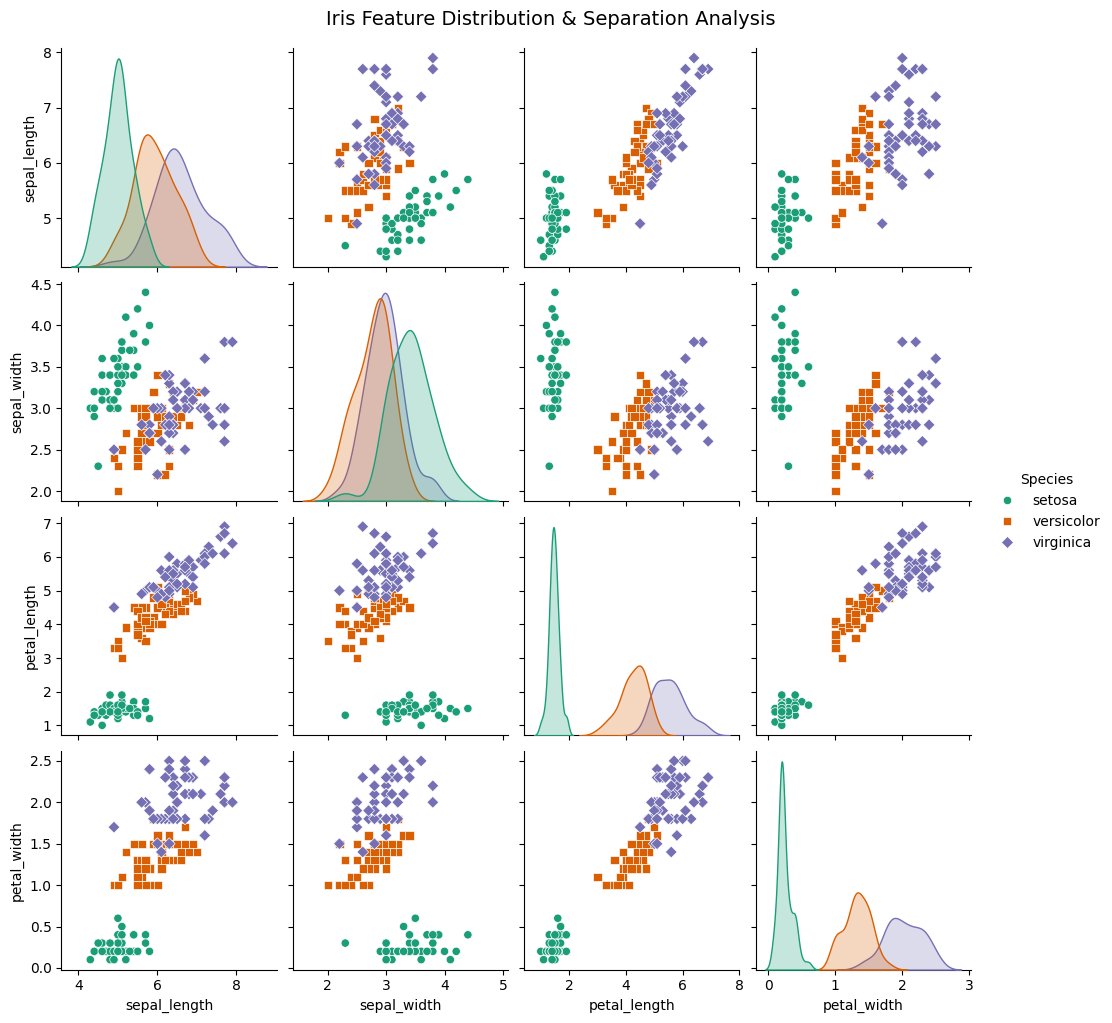

In [24]:
df['Species'] = [iris_data.target_names[i] for i in y]


# GRAPH 1: Pair Plot (Data Distribution & Separation Check)
plt.figure(figsize=(10, 8))
sns.pairplot(df, hue='Species', palette='Dark2', markers=["o", "s", "D"])
plt.suptitle("Iris Feature Distribution & Separation Analysis", y=1.02, fontsize=14)
plt.savefig("1_iris_pairplot.png", bbox_inches='tight')
plt.show()

# Split, Scale, and Train

In [25]:
# ==========================================
# Split, Scale, and Train
# ==========================================

# Step A: Train-Test Split (Shuffling auto-enabled to remove order bias)
# 80% training  20% validation/testing split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Step B: Feature Scaling using StandardScaler (Mean=0, Variance=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step C: Apply KNN Algorithm
# Train with default k=5 
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Generate predictions on the test set
y_pred = knn_model.predict(X_test_scaled)



# Metrics & Evaluation


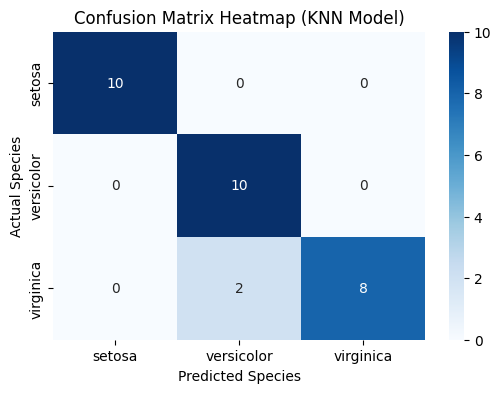

In [26]:
# ==========================================
# Metrics & Evaluation
# ==========================================

# Step A: Generate Confusion Matrix 
conf_matrix = confusion_matrix(y_test, y_pred)

# GRAPH 2: Confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_matrix, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=iris_data.target_names, 
    yticklabels=iris_data.target_names
)
plt.title("Confusion Matrix Heatmap (KNN Model)", fontsize=12)
plt.xlabel("Predicted Species", fontsize=10)
plt.ylabel("Actual Species", fontsize=10)
plt.savefig("2_confusion_matrix.png", bbox_inches='tight')
plt.show()



In [27]:
# Step B: Calculate F1 Score  (For multiclass we use 'macro' or 'weighted' average)
f1_macro = f1_score(y_test, y_pred, average='macro')
print(f"\nMacro F1-Score: {f1_macro:.4f}\n")

print("Detailed Classification Report:\n", 
      classification_report(y_test, y_pred, target_names=iris_data.target_names))


Macro F1-Score: 0.9327

Detailed Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



# Decision Boundary Visual 


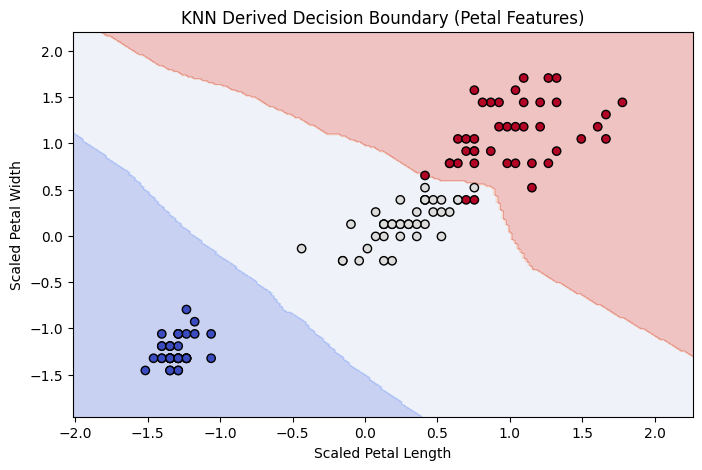

In [28]:
# GRAPH 3: Decision Boundary Visual (Using 2 Main Features)
X_visual = X_train_scaled[:, 2:]  #Use only  Petal Length and Petal Width 
knn_visual = KNeighborsClassifier(n_neighbors=5)
knn_visual.fit(X_visual, y_train)

x_min, x_max = X_visual[:, 0].min() - 0.5, X_visual[:, 0].max() + 0.5
y_min, y_max = X_visual[:, 1].min() - 0.5, X_visual[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

Z = knn_visual.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
scatter = plt.scatter(X_visual[:, 0], X_visual[:, 1], c=y_train, cmap=plt.cm.coolwarm, edgecolors='k')
plt.title("KNN Derived Decision Boundary (Petal Features)", fontsize=12)
plt.xlabel("Scaled Petal Length", fontsize=10)
plt.ylabel("Scaled Petal Width", fontsize=10)
plt.savefig("3_decision_boundary.png", bbox_inches='tight')
plt.show()
